### 🛒 Retail Sales Forecasting & Inventory Optimization
#### EDA Walkthrough Notebook

In [6]:
# ── Setup & Imports ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import sys
import openpyxl

warnings.filterwarnings('ignore')
#plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# Add project root to path
sys.path.insert(0, '..')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [7]:
print("Pandas:", pd.__version__)
print("OpenPyXL:", openpyxl.__version__)

Pandas: 2.3.3
OpenPyXL: 3.1.5


In [8]:
# Generate dataset 
raw_path = 'data/raw_sales_data.csv'
proc_path = 'data/processed_sales_data.csv'
df_raw=pd.read_csv(raw_path, parse_dates=['date'])

print(f'Shape: {df_raw.shape}')
df_raw.head(5)

Shape: (109600, 18)


,Unnamed: 0,date,store,category,product,unit_price,discount_pct,effective_price,demand,actual_sales,lost_sales,revenue,current_stock,reorder_point,reorder_qty,lead_time,is_promotion,stockout_flag
0,0,2022-01-01,Store_Delhi,Electronics,Smartphone,15000,0.00,15000.00,44,44,0,660000.00,484,37,450,9,0,0
1,1,2022-01-02,Store_Delhi,Electronics,Smartphone,15000,0.00,15000.00,37,37,0,555000.00,447,37,0,9,0,0
2,2,2022-01-03,Store_Delhi,Electronics,Smartphone,15000,0.00,15000.00,32,32,0,480000.00,415,37,0,9,0,0
3,3,2022-01-04,Store_Delhi,Electronics,Smartphone,15000,0.00,15000.00,28,28,0,420000.00,387,37,0,9,0,0
4,4,2022-01-05,Store_Delhi,Electronics,Smartphone,15000,0.00,15000.00,28,28,0,420000.00,359,37,0,9,0,0


In [10]:
df_raw.shape

(109600, 18)

In [3]:


# -----------------------------------------------
# Product Catalog
# -----------------------------------------------
PRODUCTS = {
    "Electronics": [
        ("Smartphone",    15000, 25),
        ("Laptop",        45000, 10),
        ("Earbuds",        2500, 60),
        ("Smart Watch",    8000, 30),
    ],
    "Grocery": [
        ("Rice (5kg)",      250, 200),
        ("Cooking Oil (1L)",150, 180),
        ("Wheat Flour (5kg)",200, 220),
        ("Dal (1kg)",       120, 250),
    ],
    "Clothing": [
        ("Men T-Shirt",    599,  80),
        ("Women Kurti",    899,  70),
        ("Kids Jeans",     799,  50),
        ("Sports Shoes",  1999,  40),
    ],
    "Home & Kitchen": [
        ("Pressure Cooker",1500, 30),
        ("Non-Stick Pan",   800, 45),
        ("Water Bottle",    350, 90),
        ("Mixer Grinder",  3500, 20),
    ],
    "Personal Care": [
        ("Shampoo (200ml)", 180, 150),
        ("Face Wash",       120, 160),
        ("Moisturizer",     250, 100),
        ("Toothpaste",       80, 300),
    ],
}

STORES = ["Store_Delhi", "Store_Mumbai", "Store_Bangalore",
          "Store_Chennai", "Store_Hyderabad"]
start_date=df_raw["date"].min().date()
end_date=df_raw["date"].max().date()
seed =42 
np.random.seed(seed)
#ensure_dirs(["data"])
dates      = pd.date_range(start=start_date, end=end_date, freq="D")
records    = []
print(f" data from {start_date} to {end_date} ...")
print(f"   Stores: {len(STORES)} | Date range: {len(dates)} days")
total_products = sum(len(v) for v in PRODUCTS.values())
print("Total product", total_products)

 data from 2022-01-01 to 2024-12-31 ...
   Stores: 5 | Date range: 1096 days
Total product 20


In [7]:
# -----------------------------------------------
# Seasonality & Promotion Simulation
# -----------------------------------------------
def get_seasonality_factor(date: pd.Timestamp, category: str) -> float:
    """
    Returns a multiplier based on month/season and category.
    Simulates festival seasons, summer peaks, etc.
    """
    month = date.month
    day_of_week = date.dayofweek

    # Base weekend boost
    weekend_boost = 1.25 if day_of_week >= 5 else 1.0

    # Category-specific seasonality
    season_map = {
        "Electronics": {10: 1.8, 11: 2.2, 12: 2.0, 1: 1.3},    # Diwali, Xmas, New Year
        "Grocery":     {10: 1.4, 11: 1.3, 4: 1.2, 8: 1.2},      # Festivals, summer
        "Clothing":    {10: 1.9, 11: 1.8, 2: 1.5, 9: 1.4},      # Festive, New Year, Navratri
        "Home & Kitchen": {10: 1.6, 11: 1.5, 1: 1.3},
        "Personal Care": {4: 1.3, 5: 1.3, 6: 1.2},              # Summer skincare
    }

    cat_boost = season_map.get(category, {}).get(month, 1.0)
    return cat_boost * weekend_boost

In [4]:
def simulate_promotion(date: pd.Timestamp) -> tuple:
    """
    Returns (is_promotion, discount_pct) for a given date.
    Sale events: Republic Day, Holi, Independence Day, Diwali, End-of-season
    """
    month, day = date.month, date.day

    # Simulate major sale periods
    sale_periods = [
        (1, 26, 0.20),   # Republic Day Sale
        (3, 10, 0.15),   # Holi Sale
        (8, 15, 0.18),   # Independence Day Sale
        (10, 24, 0.30),  # Diwali Sale
        (11, 11, 0.35),  # Singles Day / Big Billion
        (12, 25, 0.25),  # Christmas Sale
    ]
    for (m, d, disc) in sale_periods:
        if month == m and abs(day - d) <= 3:
            return 1, disc

    # Random weekend promo (10% probability)
    if date.dayofweek >= 5 and np.random.rand() < 0.10:
        return 1, round(np.random.uniform(0.05, 0.15), 2)

    return 0, 0.0



In [5]:
for store in STORES:
        for category, product_list in PRODUCTS.items():
            for (product, unit_price, base_demand) in product_list:

                # Simulate current stock (start random)
                current_stock = int(np.random.uniform(base_demand * 2, base_demand * 5))
                reorder_point = int(base_demand * 1.5)
                lead_time     = np.random.randint(5, 10)

                for date in dates:
                    # Seasonality + noise
                    season_factor  = get_seasonality_factor(date, category)
                    noise          = np.random.normal(1.0, 0.15)
                    raw_demand     = base_demand * season_factor * max(noise, 0.1)

                    is_promo, discount_pct = simulate_promotion(date)

                    # Promotions boost demand
                    if is_promo:
                        raw_demand *= (1 + discount_pct * 2)

                    demand = int(round(raw_demand))

                    # Stockout logic
                    actual_sales  = min(demand, current_stock)
                    lost_sales    = demand - actual_sales
                    stockout_flag = 1 if lost_sales > 0 else 0

                    # Update stock
                    current_stock -= actual_sales

                    # Reorder simulation
                    reorder_qty = 0
                    if current_stock <= reorder_point:
                        reorder_qty    = base_demand * lead_time * 2
                        current_stock += int(reorder_qty)

                    # Revenue
                    effective_price = unit_price * (1 - discount_pct)
                    revenue         = actual_sales * effective_price

                    records.append({
                        "date":           date,
                        "store":          store,
                        "category":       category,
                        "product":        product,
                        "unit_price":     unit_price,
                        "discount_pct":   discount_pct,
                        "effective_price":round(effective_price, 2),
                        "demand":         demand,
                        "actual_sales":   actual_sales,
                        "lost_sales":     lost_sales,
                        "revenue":        round(revenue, 2),
                        "current_stock":  current_stock,
                        "reorder_point":  reorder_point,
                        "reorder_qty":    reorder_qty,
                        "lead_time":      lead_time,
                        "is_promotion":   is_promo,
                        "stockout_flag":  stockout_flag,
                    })
                df1 = pd.DataFrame(records)
                print(df1)
               # df.to_csv('output.csv', index=False)
                df1.to_csv( "data/raw_sales_data.csv")
                print(f" Dataset shape: {df1.shape}")

NameError: name 'get_seasonality_factor' is not defined

In [11]:
# Basic info
print('=== DATASET INFO ===')
print(f'Date range : {df_raw["date"].min().date()} → {df_raw["date"].max().date()}')
print(f'Stores     : {df_raw["store"].unique()}')
print(f'Categories : {df_raw["category"].unique()}')
print(f'Products   : {df_raw["product"].nunique()}')
print(f'Total rows : {len(df_raw):,}')
print()
print('Missing values:')
print(df_raw.isnull().sum())

=== DATASET INFO ===
Date range : 2022-01-01 → 2024-12-31
Stores     : ['Store_Delhi' 'Store_Mumbai' 'Store_Bangalore' 'Store_Chennai'
 'Store_Hyderabad']
Categories : ['Electronics' 'Grocery' 'Clothing' 'Home & Kitchen' 'Personal Care']
Products   : 20
Total rows : 109,600

Missing values:
Unnamed: 0         0
date               0
store              0
category           0
product            0
unit_price         0
discount_pct       0
effective_price    0
demand             0
actual_sales       0
lost_sales         0
revenue            0
current_stock      0
reorder_point      0
reorder_qty        0
lead_time          0
is_promotion       0
stockout_flag      0
dtype: int64


#### preprocess the data

In [12]:
# Drop rows where date is missing

before = len(df_raw)
df_raw.dropna(subset=["date"], inplace=True)
dropped = before - len(df_raw)
if dropped > 0:
    print(f"  Dropped {dropped} rows with null dates.")

 # Fill numeric nulls
    numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        null_count = df_raw[col].isnull().sum()
        if null_count > 0:
            median_val = df_raw[col].median()
            df_raw[col].fillna(median_val, inplace=True)
            print(f"Filled {null_count} nulls in '{col}' with median ({median_val:.2f})")

 # Fill string nulls
    str_cols = df_raw.select_dtypes(include=["object"]).columns.tolist()
    for col in str_cols:
        null_count = df_raw[col].isnull().sum()
        if null_count > 0:
            df_raw[col].fillna("Unknown", inplace=True)
            print(f"Filled {null_count} nulls in '{col}' with 'Unknown'")

print(f" Missing values handled. Remaining nulls: {df_raw.isnull().sum().sum()}")

 Missing values handled. Remaining nulls: 0


In [13]:
### Ensures correct data types for all columns.
df_raw["date"]          = pd.to_datetime(df_raw["date"])
df_raw["actual_sales"]  = df_raw["actual_sales"].astype(int)
df_raw["demand"]        = df_raw["demand"].astype(int)
df_raw["current_stock"] = df_raw["current_stock"].astype(int)
df_raw["stockout_flag"] = df_raw["stockout_flag"].astype(int)
df_raw["is_promotion"]  = df_raw["is_promotion"].astype(int)
df_raw["unit_price"]    = df_raw["unit_price"].astype(float)
df_raw["revenue"]       = df_raw["revenue"].astype(float)
print(" Data types fixed.")


 Data types fixed.


In [14]:
### Removes duplicate rows (same store+product+date = duplicate).
subset = ["date", "store", "product"]
before = len(df_raw)
df_raw.drop_duplicates(subset=subset, keep="first", inplace=True)
removed = before - len(df_raw)
print(f" Removed {removed} duplicate rows. Remaining: {len(df_raw):,}")

 Removed 0 duplicate rows. Remaining: 109,600


In [15]:
#Caps outliers using IQR * multiplier method.    Values above upper bound are clipped to upper bound.
multiplier: float = 3.0
for col in ["actual_sales", "demand", "revenue"]:
    Q1  = df_raw[col].quantile(0.25)
    Q3  = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    before_count = ((df_raw[col] < lower) | (df_raw[col] > upper)).sum()
    df_raw[col] = df_raw[col].clip(lower=lower, upper=upper)
    print(f"   Capped {before_count} outliers in '{col}' → [{lower:.1f}, {upper:.1f}]")


   Capped 122 outliers in 'actual_sales' → [-417.0, 661.0]
   Capped 121 outliers in 'demand' → [-420.0, 665.0]
   Capped 14003 outliers in 'revenue' → [-166470.0, 299765.0]


In [16]:
### sort and reset index 
df_raw = df_raw.sort_values(["store", "product", "date"]).reset_index(drop=True)
print(" Data sorted by [store → product → date].")

 Data sorted by [store → product → date].


In [17]:
### Aggregates data to daily level per store+product.    Useful for forecasting models.
agg = df_raw.groupby(["date", "store", "category", "product"]).agg(
        actual_sales   = ("actual_sales",   "sum"),
        demand         = ("demand",         "sum"),
        revenue        = ("revenue",        "sum"),
        current_stock  = ("current_stock",  "last"),
        is_promotion   = ("is_promotion",   "max"),
        stockout_flag  = ("stockout_flag",  "max"),
        unit_price     = ("unit_price",     "first"),
        discount_pct   = ("discount_pct",   "mean"),
    ).reset_index()

print(f" Aggregated to {len(agg):,} daily records.")

 Aggregated to 109,600 daily records.


In [18]:
### Fills missing dates within each store-product group.    Ensures a continuous time series without gaps.
freq: str = "D"
dfs = []
groups = df_raw.groupby(["store", "product"])
for (store, product), group in groups:
    group = group.set_index("date").asfreq(freq)
    group["store"]    = store
    group["product"]  = product
    # Forward-fill metadata, zero-fill sales
    meta_cols  = ["category", "unit_price"]
    sales_cols = ["actual_sales", "demand", "revenue","is_promotion", "stockout_flag", "discount_pct"]
    group[meta_cols]  = group[meta_cols].ffill()
    group[sales_cols] = group[sales_cols].fillna(0)
    group["current_stock"] = group["current_stock"].ffill()
    dfs.append(group.reset_index())
    result = pd.concat(dfs, ignore_index=True)
    print(f" Date gaps filled. New shape: {result.shape}")

 Date gaps filled. New shape: (1096, 18)
 Date gaps filled. New shape: (2192, 18)
 Date gaps filled. New shape: (3288, 18)
 Date gaps filled. New shape: (4384, 18)
 Date gaps filled. New shape: (5480, 18)
 Date gaps filled. New shape: (6576, 18)
 Date gaps filled. New shape: (7672, 18)
 Date gaps filled. New shape: (8768, 18)
 Date gaps filled. New shape: (9864, 18)
 Date gaps filled. New shape: (10960, 18)
 Date gaps filled. New shape: (12056, 18)
 Date gaps filled. New shape: (13152, 18)
 Date gaps filled. New shape: (14248, 18)
 Date gaps filled. New shape: (15344, 18)
 Date gaps filled. New shape: (16440, 18)
 Date gaps filled. New shape: (17536, 18)
 Date gaps filled. New shape: (18632, 18)
 Date gaps filled. New shape: (19728, 18)
 Date gaps filled. New shape: (20824, 18)
 Date gaps filled. New shape: (21920, 18)
 Date gaps filled. New shape: (23016, 18)
 Date gaps filled. New shape: (24112, 18)
 Date gaps filled. New shape: (25208, 18)
 Date gaps filled. New shape: (26304, 18)
 

In [19]:
## save process data in new file 

df_raw.to_csv("data/processed_sales_data.csv")
# Print preprocessing summary
print("\n" + "="*55)
print("  PREPROCESSING COMPLETE")
print("="*55)
stats = df_raw.describe(include="all").T
stats["missing"] = df_raw.isnull().sum()
stats["missing_%"] = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
print(stats[["count", "mean", "std", "min", "max", "missing", "missing_%"]].head(10))
print("="*55)
print(" Preprocessing pipeline completed successfully.")


  PREPROCESSING COMPLETE
                    count                 mean      std                  min  \
Unnamed: 0      109600.00             54799.50 31638.94                 0.00   
date               109600  2023-07-02 12:00:00      NaN  2022-01-01 00:00:00   
store              109600                  NaN      NaN                  NaN   
category           109600                  NaN      NaN                  NaN   
product            109600                  NaN      NaN                  NaN   
unit_price      109600.00              4114.80 10007.39                80.00   
discount_pct    109600.00                 0.03     0.08                 0.00   
effective_price 109600.00              3992.22  9748.68                52.00   
demand          109600.00               133.53   112.15                 5.00   
actual_sales    109600.00               133.26   111.93                 5.00   

                                 max  missing  missing_%  
Unnamed: 0                 109599.

#### 📊 Step 2 — Exploratory Data Analysis (EDA)

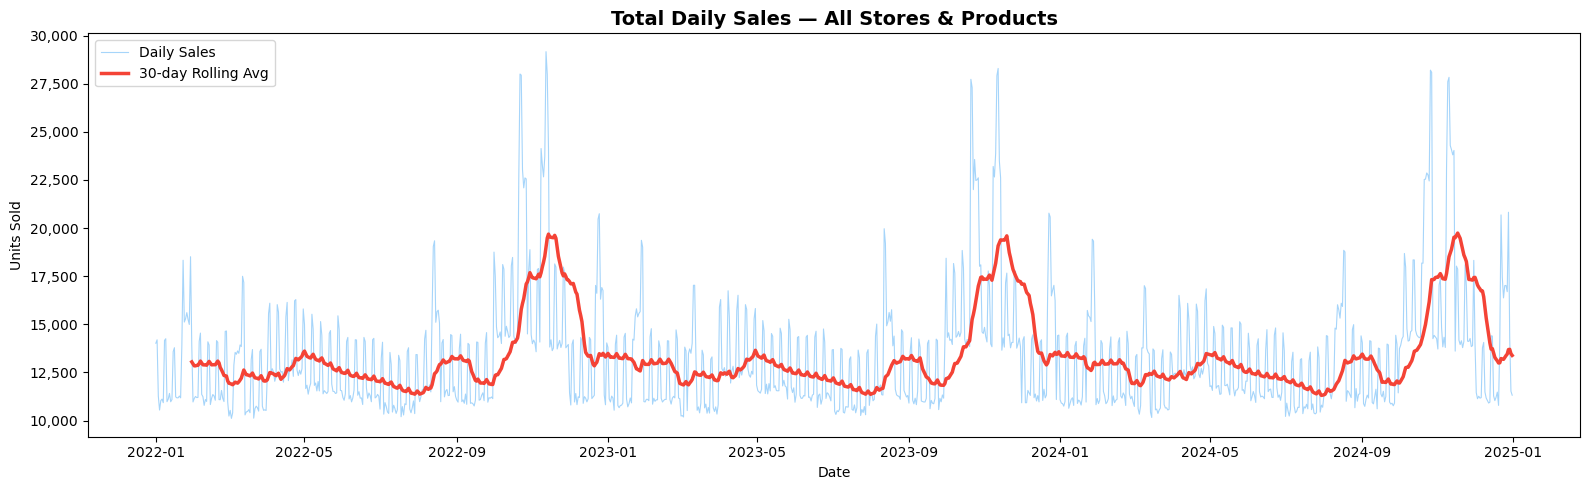

Key Insight: Clear seasonal spikes in Oct-Nov (Diwali) and Dec-Jan (New Year)


In [20]:
# ── 2.1 Total Sales Trend ──────────────────────────────────
daily = df_raw.groupby('date')['actual_sales'].sum().reset_index()
daily['rolling_30d'] = daily['actual_sales'].rolling(30).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily['date'], daily['actual_sales'], alpha=0.4, color='#2196F3', linewidth=0.8, label='Daily Sales')
ax.plot(daily['date'], daily['rolling_30d'], color='#F44336', linewidth=2.5, label='30-day Rolling Avg')
ax.set_title('Total Daily Sales — All Stores & Products', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('images/nb_01_sales_trend.png', dpi=120)
plt.show()
print('Key Insight: Clear seasonal spikes in Oct-Nov (Diwali) and Dec-Jan (New Year)')

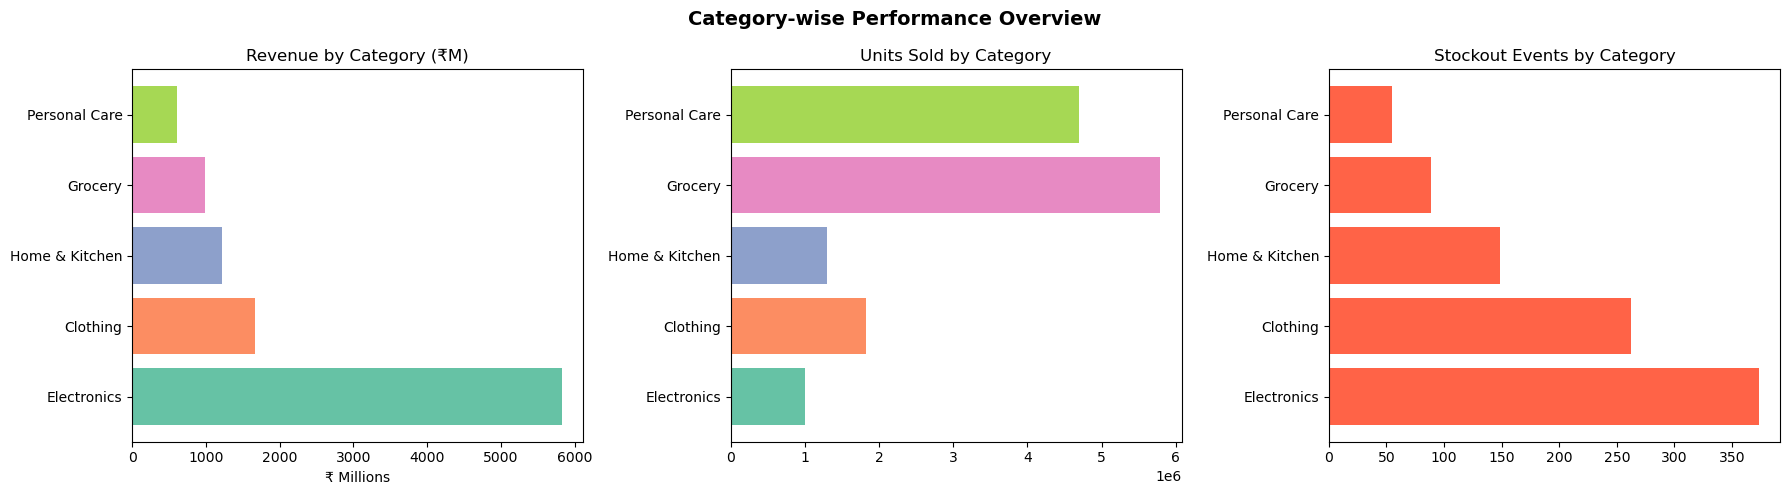

      category       Revenue   Units  Stockouts
   Electronics 5825659760.00 1000419        373
      Clothing 1667502004.77 1820857        262
Home & Kitchen 1215715106.00 1295900        149
       Grocery  982502658.60 5789653         89
 Personal Care  604656977.60 4698753         55


In [21]:
# ── 2.2 Category Analysis ──────────────────────────────────
cat_rev = df_raw.groupby('category').agg(
    Revenue=('revenue','sum'),
    Units=('actual_sales','sum'),
    Stockouts=('stockout_flag','sum')
).reset_index().sort_values('Revenue', ascending=False)

fig, axes = plt.subplots(1,3, figsize=(18,5))
colors = sns.color_palette('Set2', len(cat_rev))

axes[0].barh(cat_rev['category'], cat_rev['Revenue']/1e6, color=colors)
axes[0].set_title('Revenue by Category (₹M)')
axes[0].set_xlabel('₹ Millions')

axes[1].barh(cat_rev['category'], cat_rev['Units'], color=colors)
axes[1].set_title('Units Sold by Category')

axes[2].barh(cat_rev['category'], cat_rev['Stockouts'], color='tomato')
axes[2].set_title('Stockout Events by Category')

plt.suptitle('Category-wise Performance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/nb_02_category_analysis.png', dpi=120)
plt.show()

print(cat_rev.to_string(index=False))

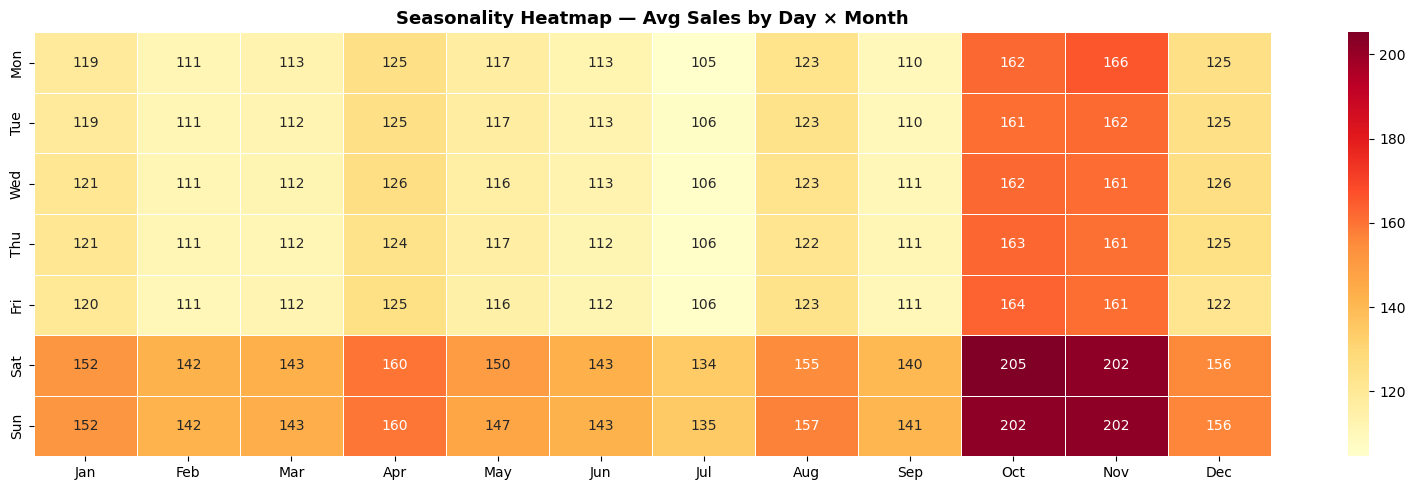

Hot spots: Oct-Nov weekends = peak demand (Diwali season)


In [23]:
# ── 2.3 Seasonality Heatmap ────────────────────────────────
df2 = df_raw.copy()
df2['month'] = df2['date'].dt.month
df2['day_of_week'] = df2['date'].dt.dayofweek

pivot = df2.pivot_table(values='actual_sales', index='day_of_week', columns='month', aggfunc='mean')
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(16,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Seasonality Heatmap — Avg Sales by Day × Month', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/nb_03_seasonality.png', dpi=120)
plt.show()
print('Hot spots: Oct-Nov weekends = peak demand (Diwali season)')

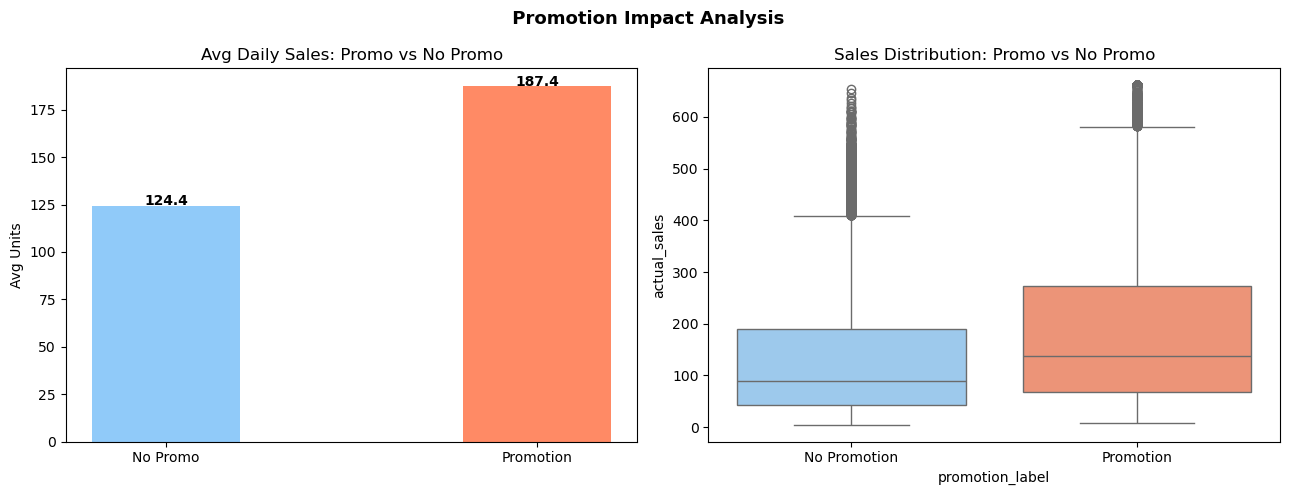


 Promotion Sales Uplift: +50.6%


In [24]:
# ── 2.4 Promotion Impact ───────────────────────────────────

# Clean promotion column
df_raw['is_promotion'] = (
    df_raw['is_promotion']
    .astype(str)
    .str.strip()
    .replace({'0': 0, '1': 1})
)

# Convert to integer
df_raw['is_promotion'] = pd.to_numeric(
    df_raw['is_promotion'],
    errors='coerce'
)

# Remove rows where promotion or sales is missing
plot_df = df_raw.dropna(
    subset=['is_promotion', 'actual_sales']
).copy()

# Make promotion categorical for plotting
plot_df['promotion_label'] = plot_df['is_promotion'].map({
    0: 'No Promotion',
    1: 'Promotion'
})

promo = df_raw.groupby('is_promotion')['actual_sales'].agg(['mean','median','std']).reset_index()
promo['is_promotion'] = promo['is_promotion'].map({0:'No Promo', 1:'Promotion'})

fig, axes = plt.subplots(1,2, figsize=(13,5))

axes[0].bar(promo['is_promotion'], promo['mean'], color=['#90CAF9','#FF8A65'], width=0.4)
axes[0].set_title('Avg Daily Sales: Promo vs No Promo')
axes[0].set_ylabel('Avg Units')
for i, v in enumerate(promo['mean']):
    axes[0].text(i, v+0.3, f'{v:.1f}', ha='center', fontweight='bold')

sns.boxplot(
    data=plot_df,
    x='promotion_label',
    y='actual_sales',
    hue='promotion_label',
    palette={
        'No Promotion': '#90CAF9',
        'Promotion': '#FF8A65'
    },
    legend=False,
    ax=axes[1]
)
#sns.boxplot(data=df_raw, x='is_promotion', y='actual_sales', 
#            palette={0:'#90CAF9',1:'#FF8A65'}, ax=axes[1])
axes[1].set_title('Sales Distribution: Promo vs No Promo')
axes[1].set_xticklabels(['No Promotion','Promotion'])

plt.suptitle(' Promotion Impact Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/nb_04_promotion_impact.png', dpi=120)
plt.show()

uplift = (promo.loc[1,'mean'] - promo.loc[0,'mean']) / promo.loc[0,'mean'] * 100
print(f'\n Promotion Sales Uplift: +{uplift:.1f}%')

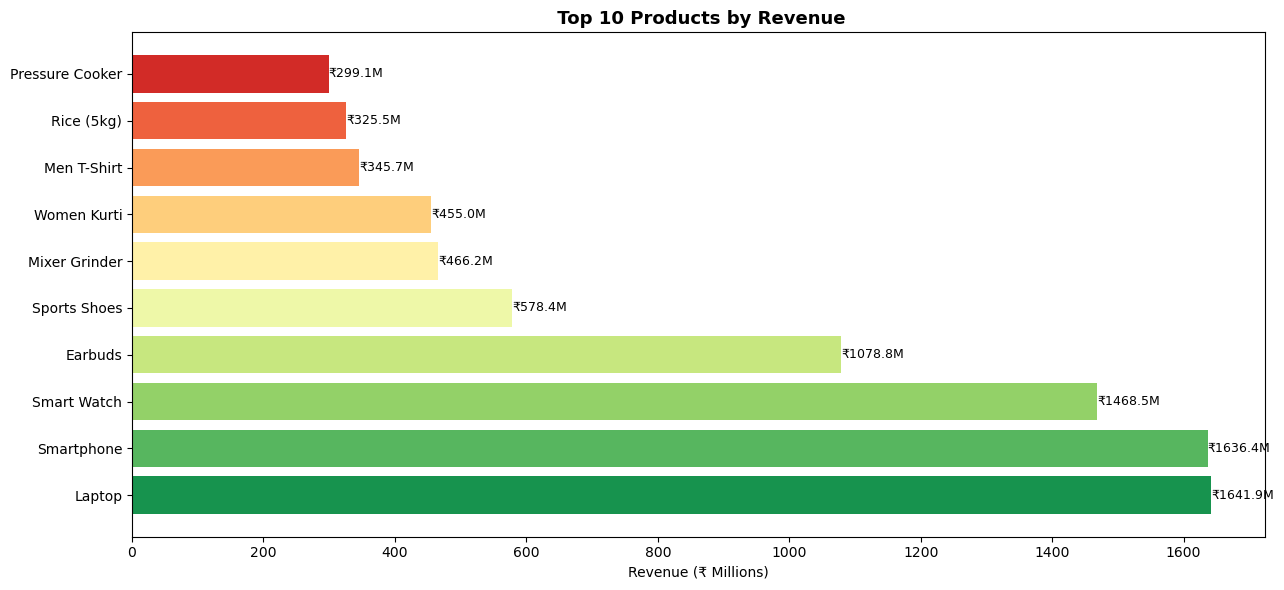

In [25]:
# ── 2.5 Top Products by Revenue ────────────────────────────
top_products = df_raw.groupby(['product','category'])['revenue'].sum().reset_index()\
                      .sort_values('revenue', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(13,6))
colors = sns.color_palette('RdYlGn_r', len(top_products))
bars = ax.barh(top_products['product'], top_products['revenue']/1e6, color=colors)
ax.set_title(' Top 10 Products by Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (₹ Millions)')
for bar, val in zip(bars, top_products['revenue']):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
            f'₹{val/1e6:.1f}M', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('images/nb_05_top_products.png', dpi=120)
plt.show()

####  Step 3 — Feature Engineering Preview

In [26]:
df = pd.read_csv("data/processed_sales_data.csv", parse_dates=["date"])
df = df.reset_index(drop=True)
date_col: str = "date"
#### add_date_features in df
df[date_col] = pd.to_datetime(df[date_col])
df["year"]         = df[date_col].dt.year
df["month"]        = df[date_col].dt.month
df["day"]          = df[date_col].dt.day
df["day_of_week"]  = df[date_col].dt.dayofweek
df["week_of_year"] = df[date_col].dt.isocalendar().week.astype(int)
df["quarter"]      = df[date_col].dt.quarter
df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)
df["is_month_start"] = df[date_col].dt.is_month_start.astype(int)
df["is_month_end"]   = df[date_col].dt.is_month_end.astype(int)
df["day_of_year"]  = df[date_col].dt.dayofyear

###add_lag_features
target_col: str = "actual_sales"
lags=[1,7,14,30]
windows=[7,14,30]
df = df.copy().reset_index(drop=True)
df = df.sort_values(["store", "product", "date"])
for lag in lags:
    df[f"lag_{lag}d"] = df.groupby(["store","product"])[target_col].shift(lag)

print("Lag features added.")


###  add_rolling_features
for w in windows:
    df[f"rolling_mean_{w}d"] = (
        df.groupby(["store","product"])[target_col].transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    )
    df[f"rolling_std_{w}d"] = (
        df.groupby(["store","product"])[target_col].transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())
        )

print("Rolling features added.")

#### Expend Features 
df["expanding_mean"] = (df.groupby(["store","product"])[target_col].transform(lambda x: x.expanding().mean()))
print(" Expanding mean feature added.")

#### Add Promotional Feature
df["promo_x_weekend"] = df["is_promotion"] * df.get("is_weekend", 0)
df["promo_x_month"]   = df["is_promotion"] * df.get("month", 1)
df["promo_lag1"] = (df.groupby(["store","product"])["is_promotion"].shift(1).fillna(0).astype(int))

print(" Promotion features added.")

#### Encoding
store_map    = {s:i for i,s in enumerate(df["store"].unique())}
category_map = {c:i for i,c in enumerate(df["category"].unique())}
product_map  = {p:i for i,p in enumerate(df["product"].unique())}

df["store_enc"]    = df["store"].map(store_map)
df["category_enc"] = df["category"].map(category_map)
df["product_enc"]  = df["product"].map(product_map)
enc_maps={"store":store_map,"category":category_map,"product":product_map}
print(" Encoding done.")

####  Demand Segmentation
result = []
for (store, product), group in df.groupby(["store","product"]):
    avg_sales = group[target_col].mean()
    zero_pct  = (group[target_col]==0).mean()

    if zero_pct > 0.4:
        seg = "INTERMITTENT"
    elif avg_sales >= group[target_col].quantile(0.75):
        seg = "HIGH"
    elif avg_sales <= group[target_col].quantile(0.25):
        seg = "LOW"
    else:
        seg = "MEDIUM"

    group = group.copy()
    group["demand_segment"] = seg
    result.append(group)

df = pd.concat(result, ignore_index=True)
print(" Demand segmentation done.")

df.dropna(subset=["lag_7d","rolling_mean_7d"], inplace=True)

df = df.sort_values(["store","product","date"]).reset_index(drop=True)

df.to_csv("data/features_data.csv")

print(f" Feature engineering complete. Shape: {df.shape}")

Lag features added.
Rolling features added.
 Expanding mean feature added.
 Promotion features added.
 Encoding done.
 Demand segmentation done.
 Feature engineering complete. Shape: (108900, 47)


In [27]:
# Load feature data
feat_path = 'data/features_data.csv'
if os.path.exists(feat_path):
    df_feat = pd.read_csv(feat_path, parse_dates=['date'])
    print(f'Features shape: {df_feat.shape}')
    print('\nNew feature columns:')
    new_cols = [c for c in df_feat.columns if any(x in c for x in 
                ['lag','rolling','expanding','enc','week','month','quarter','is_','promo'])]
    print(new_cols)
    df_feat[new_cols[:8]].describe().round(2)
else:
    print(' NO file exist features_data.csv')

Features shape: (108900, 48)

New feature columns:
['is_promotion', 'stockout_flag', 'month', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d', 'rolling_mean_7d', 'rolling_std_7d', 'rolling_mean_14d', 'rolling_std_14d', 'rolling_mean_30d', 'rolling_std_30d', 'expanding_mean', 'promo_x_weekend', 'promo_x_month', 'promo_lag1', 'store_enc', 'category_enc', 'product_enc']


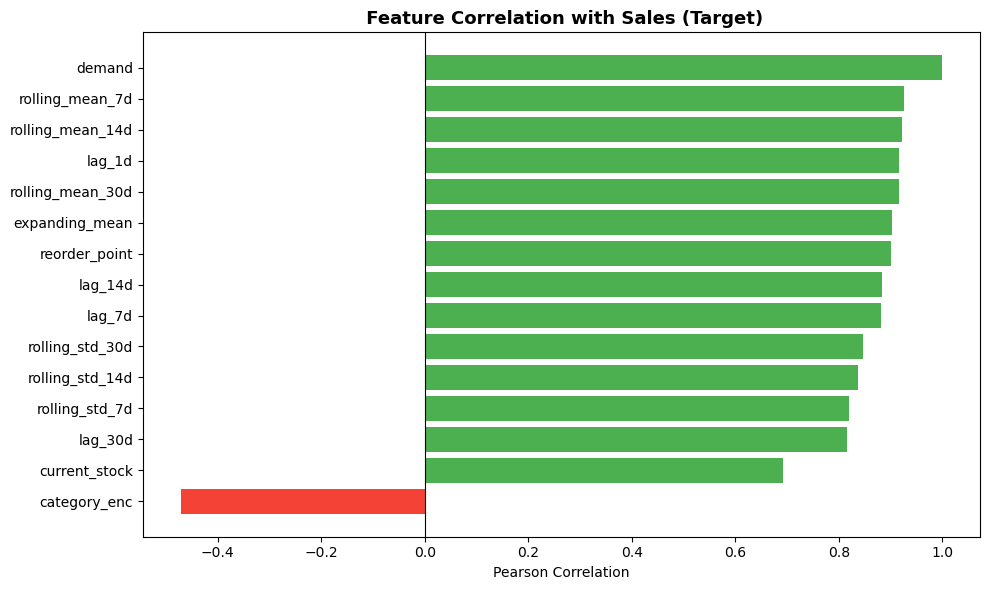

In [28]:
# Correlation heatmap of features vs target
if os.path.exists(feat_path):
    num_cols = df_feat.select_dtypes(include=np.number).columns.tolist()
    corr_with_target = df_feat[num_cols].corr()['actual_sales'].drop('actual_sales')\
                                         .sort_values(key=abs, ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#4CAF50' if v > 0 else '#F44336' for v in corr_with_target.values]
    ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
    ax.set_title(' Feature Correlation with Sales (Target)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Pearson Correlation')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig('images/nb_06_feature_correlation.png', dpi=120)
    plt.show()

####  Step 4 — Forecasting Results

In [29]:
# -----------------------------------------------
# 2. Compute Metrics
# -----------------------------------------------
def compute_metrics(y_true, y_pred, model_name: str = "") -> dict:
    """
    Computes MAE, RMSE, MAPE, R² for model evaluation.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    # MAPE: avoid divide by zero
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    metrics = {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE_%": mape, "R2": r2}
    return metrics

# -----------------------------------------------
# 8. Metric Printer
# -----------------------------------------------
def print_metrics(metrics, title):
    print("\n" + "="*40)
    print(title)
    print("="*40)

    for k, v in metrics.items():
        try:
            # Try formatting as float
            print(f"{k:<20}: {float(v):.4f}")
        except:
            # If not numeric, print as is
            print(f"{k:<20}: {v}")



In [30]:
###FORECASTING PIPELINE STARTED 
#features_path = "data/features_data.csv",
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    logger.warning(" XGBoost not installed. Skipping XGBoost model.")
    XGBOOST_AVAILABLE = False

try:
    from statsmodels.tsa.arima.model import ARIMA
    ARIMA_AVAILABLE = True
except ImportError:
    logger.warning("  Statsmodels not installed. Skipping ARIMA model.")
    ARIMA_AVAILABLE = False


ML_FEATURES = [
    "year", "month", "day", "day_of_week", "week_of_year",
    "quarter", "is_weekend", "is_month_start", "is_month_end",
    "day_of_year", "lag_1d", "lag_7d", "lag_14d", "lag_30d",
    "rolling_mean_7d", "rolling_mean_14d", "rolling_mean_30d",
    "rolling_std_7d", "rolling_std_14d",
    "expanding_mean",
    "is_promotion", "promo_x_weekend", "promo_lag1",
    "unit_price", "discount_pct",
    "store_enc", "category_enc", "product_enc",
]
forecast_path = 'outputs/forecast_results.csv'
features_path = 'data/features_data.csv'
df=pd.read_csv(features_path, parse_dates=['date'])
## Splits data by date (not random) to respect time-series nature.
train_ratio=0.8
df = df.sort_values("date").reset_index(drop=True)
split_idx = int(len(df) * train_ratio)
split_date = df.iloc[split_idx]["date"]

train = df[df["date"] < split_date].copy()
test  = df[df["date"] >= split_date].copy()

print(f"Train: {len(train):,} rows | Test: {len(test):,} rows")
print(f"   Split date: {split_date.date()}")

target = "actual_sales"
# --- Naive Baseline ---
 ###Baseline model: predicts using 7-day rolling mean from training data.

last_7 = train[target].tail(7).mean()
y_pred = np.full(len(test), last_7)
y_true = test[target].values
metrics = compute_metrics(y_true, y_pred, "Naive Baseline")
print(f"Naive baseline MAE: {metrics['MAE']:.2f}")
naive_metrics=metrics
naive_pred = y_pred
# --- Random Forest ---
## Trains a Random Forest Regressor and evaluates on test set.
n_estimators= 100
max_depth = 10
save_path= "models/rf_model.pkl"
feature_cols = [c for c in ML_FEATURES if c in train.columns]
X_train = train[feature_cols].fillna(0)
y_train = train[target]
X_test  = test[feature_cols].fillna(0)
y_test  = test[target]
print(f" Training Random Forest with {n_estimators} trees...")
rf = RandomForestRegressor(
    n_estimators = n_estimators,
    max_depth    = max_depth,
    random_state = 42,
    n_jobs       = -1
)
rf.fit(X_train, y_train)

y_pred  = rf.predict(X_test)
y_pred  = np.maximum(y_pred, 0)   # No negative sales
rf_metrics = compute_metrics(y_test.values, y_pred, "Random Forest")
print_metrics(rf_metrics, "Random Forest Metrics")
rf_pred=y_pred
rf_model=rf
# Feature importance
fi_df = pd.DataFrame({
    "feature":   feature_cols,"importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)
rf_fi=fi_df
 # Save model
joblib.dump(rf, save_path)
print(f" Random Forest saved → {save_path}")

 # --- XGBoost ---

n_estimators = 100
learning_rate = 0.1
max_depth = 6
save_path = "models/xgb_model.pkl"
### Trains XGBoost model and evaluates on test set.
feature_cols = [c for c in ML_FEATURES if c in train.columns]
X_train = train[feature_cols].fillna(0)
y_train = train[target]
X_test  = test[feature_cols].fillna(0)
y_test  = test[target]

print(" Training XGBoost...")
xgb = XGBRegressor(
    n_estimators  = n_estimators,
    learning_rate = learning_rate,
    max_depth     = max_depth,
    random_state  = 42,
    verbosity     = 0
)
xgb.fit(X_train, y_train)

y_pred  = xgb.predict(X_test)
y_pred  = np.maximum(y_pred, 0)

metrics = compute_metrics(y_test.values, y_pred, "XGBoost")
print_metrics(metrics, "XGBoost Metrics")

fi_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

joblib.dump(xgb, save_path)
print(f" XGBoost saved → {save_path}")
xgb_metrics=metrics
xgb_pred=y_pred
xgb_model=xgb
xgb_fi =fi_df
 # --- Model Comparison Table ---
comparison = [naive_metrics, rf_metrics]
if xgb_metrics:
    comparison.append(xgb_metrics)
    comparison_df = pd.DataFrame(comparison)
    comparison_df = comparison_df.round(4)

print("\n" + "="*60)
print("  MODEL COMPARISON TABLE")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)
comparison_df.to_csv( "outputs/model_comparison.csv")
# --- Best Model (lowest MAE) ---
if xgb_metrics and xgb_metrics["MAE"] < rf_metrics["MAE"]:
    best_model  = xgb_model
    best_pred   = xgb_pred
    best_name   = "XGBoost"
    best_fi     = xgb_fi
else:
    best_model  = rf_model
    best_pred   = rf_pred
    best_name   = "RandomForest"
    best_fi     = rf_fi

print(f"\n Best model: {best_name}")

Train: 87,100 rows | Test: 21,800 rows
   Split date: 2024-05-28
Naive baseline MAE: 87.53
 Training Random Forest with 100 trees...

Random Forest Metrics
Model               : Random Forest
MAE                 : 18.4232
RMSE                : 29.3260
MAPE_%              : 14.2571
R2                  : 0.9351
 Random Forest saved → models/rf_model.pkl
 Training XGBoost...

XGBoost Metrics
Model               : XGBoost
MAE                 : 17.6831
RMSE                : 28.0941
MAPE_%              : 13.7758
R2                  : 0.9405
 XGBoost saved → models/xgb_model.pkl

  MODEL COMPARISON TABLE
         Model   MAE   RMSE  MAPE_%    R2
Naive Baseline 87.53 123.21  106.73 -0.15
 Random Forest 18.42  29.33   14.26  0.94
       XGBoost 17.68  28.09   13.78  0.94

 Best model: XGBoost


In [31]:
# Add predictions to test set
test_with_preds = test.copy()
test_with_preds["predicted_sales"] = best_pred
test_with_preds["residual"]        = test_with_preds[target] - best_pred

# Prediction intervals on test set
feature_cols = [c for c in ML_FEATURES if c in test.columns]
##Estimates prediction intervals using bootstrap sampling (works for tree-based models). get (lower_bound, upper_bound) arrays.
X= test[feature_cols]
n_bootstraps= 50
ci = 0.95
preds = []
n = len(X)
feature_cols = [c for c in ML_FEATURES if c in X.columns]
X_arr = X[feature_cols].fillna(0).values
for _ in range(n_bootstraps):
    # Add small noise to simulate uncertainty
    noise = np.random.normal(0, 0.05, X_arr.shape)
    X_noisy = X_arr + noise
    p = best_model.predict(X_noisy)
    preds.append(np.maximum(p, 0))

preds = np.array(preds)
alpha = 1 - ci
lower = np.percentile(preds, alpha / 2 * 100, axis=0)
upper = np.percentile(preds, (1 - alpha / 2) * 100, axis=0)
#lower, upper = compute_prediction_intervals(best_model, test[feature_cols])
test_with_preds["pred_lower"] = lower
test_with_preds["pred_upper"] = upper

test_with_preds[["date", "store", "product", "category", target, "predicted_sales", "pred_lower",
                 "pred_upper", "residual"]].to_csv("outputs/test_predictions.csv")

# --- Future Forecast ---
print(f"\n--- Generating 30-day future forecast ---")
forecast_days=30
###  Generates forecast for the next N days using the last known feature row.  Works by iteratively extending the dataset and predicting.
forecasts    = []
for (store, product), group in df.groupby(["store", "product"]):
    group = group.sort_values("date").tail(60).copy()
    last_date = group["date"].max()
    for i in range(1, forecast_days + 1):
        next_date = last_date + pd.Timedelta(days=i)

        # Build feature row from last known row
        row = group.tail(1).copy()
        row["date"]          = next_date
        row["day"]           = next_date.day
        row["month"]         = next_date.month
        row["year"]          = next_date.year
        row["day_of_week"]   = next_date.dayofweek
        row["week_of_year"]  = next_date.isocalendar().week
        row["quarter"]       = next_date.quarter
        row["is_weekend"]    = int(next_date.dayofweek >= 5)
        row["is_month_start"]= int(next_date.day == 1)
        row["is_month_end"]  = int(next_date.day == pd.Period(next_date, "M").days_in_month)
        row["day_of_year"]   = next_date.dayofyear

            # Rolling/lag from last known sales
        recent_sales = group[target].tail(30).values
        row["lag_1d"]           = recent_sales[-1] if len(recent_sales) >= 1 else 0
        row["lag_7d"]           = recent_sales[-7] if len(recent_sales) >= 7 else 0
        row["lag_14d"]          = recent_sales[-14] if len(recent_sales) >= 14 else 0
        row["lag_30d"]          = recent_sales[-30] if len(recent_sales) >= 30 else 0
        row["rolling_mean_7d"]  = np.mean(recent_sales[-7:]) if len(recent_sales) >= 7 else np.mean(recent_sales)
        row["rolling_mean_14d"] = np.mean(recent_sales[-14:]) if len(recent_sales) >= 14 else np.mean(recent_sales)
        row["rolling_mean_30d"] = np.mean(recent_sales)
        row["rolling_std_7d"]   = np.std(recent_sales[-7:])  if len(recent_sales) >= 7 else 0
        row["rolling_std_14d"]  = np.std(recent_sales[-14:]) if len(recent_sales) >= 14 else 0
        row["expanding_mean"]   = np.mean(recent_sales)
        row["is_promotion"]     = 0
        row["promo_x_weekend"]  = 0
        row["promo_lag1"]       = 0

        X_row = row[feature_cols].fillna(0)
        pred  = max(best_model.predict(X_row)[0], 0)

        forecasts.append({
            "date":         next_date,
            "store":        store,
            "product":      product,
            "category":     group["category"].iloc[-1],
            "forecast_qty": round(pred, 2),
            "unit_price":   group["unit_price"].iloc[-1],
            "forecast_revenue": round(pred * group["unit_price"].iloc[-1], 2),
            "model":        "RandomForest"
        })

forecast_df = pd.DataFrame(forecasts)
#forecast_df = generate_future_forecast(df, best_model, forecast_days=30)
forecast_df.to_csv(forecast_path)

# Save feature importance
if best_fi is not None:
    best_fi.to_csv("outputs/feature_importance.csv")

print(" Forecasting pipeline complete.")


--- Generating 30-day future forecast ---
 Forecasting pipeline complete.


In [32]:
# Load test predictions
pred_path = 'outputs/test_predictions.csv'
if os.path.exists(pred_path):
    preds = pd.read_csv(pred_path, parse_dates=['date'])
    print(f'Test predictions shape: {preds.shape}')
    preds[['date','store','product','actual_sales','predicted_sales','pred_lower','pred_upper']].head(10)
else:
    print('No  file exist')

Test predictions shape: (21800, 10)


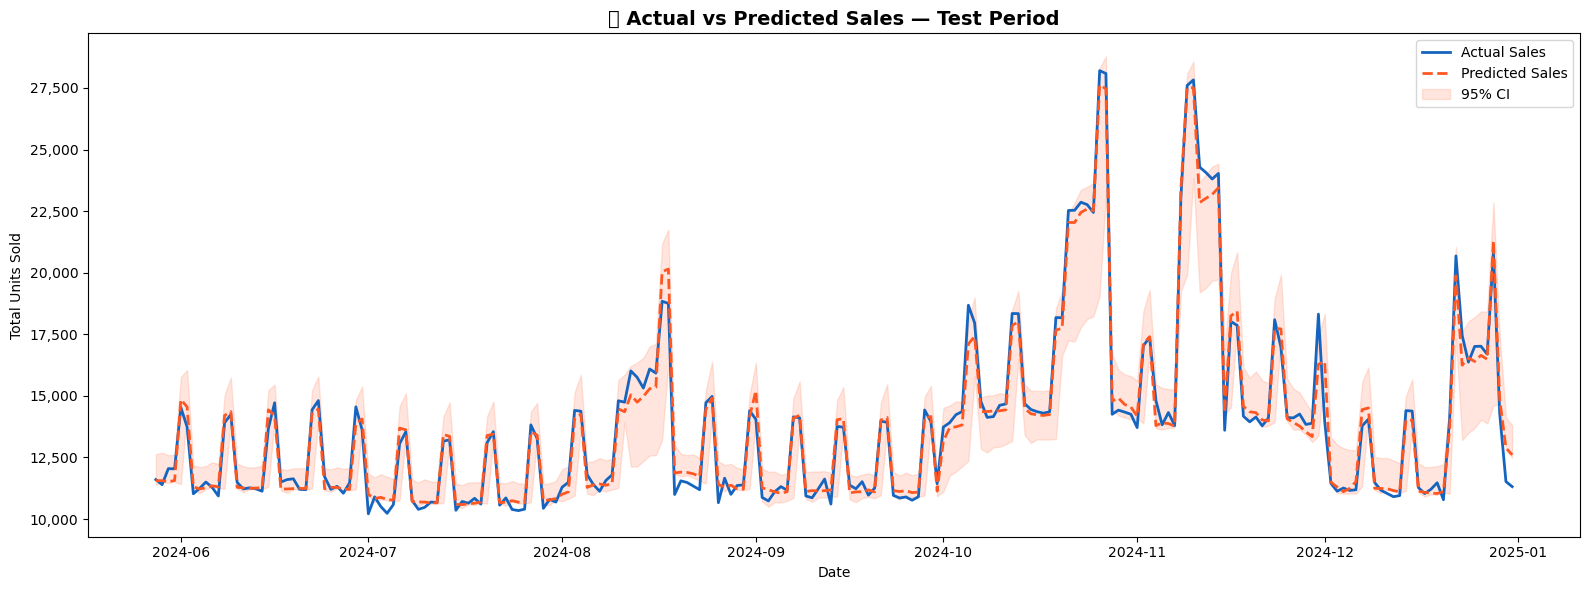


Residual Stats:
  Mean  : 17.11
  Std   : 499.89
  Max   : 2036.05
  Min   : -2421.51


In [33]:
# Actual vs Predicted with confidence band
if os.path.exists(pred_path):
    tp = preds.groupby('date').agg(
        actual=('actual_sales','sum'),
        predicted=('predicted_sales','sum'),
        lower=('pred_lower','sum'),
        upper=('pred_upper','sum')
    ).reset_index().sort_values('date')

    fig, ax = plt.subplots(figsize=(16, 6))
    ax.plot(tp['date'], tp['actual'],    label='Actual Sales',    color='#1565C0', linewidth=2)
    ax.plot(tp['date'], tp['predicted'], label='Predicted Sales', color='#FF5722', linewidth=2, linestyle='--')
    ax.fill_between(tp['date'], tp['lower'], tp['upper'], alpha=0.15, color='#FF5722', label='95% CI')
    ax.set_title('🎯 Actual vs Predicted Sales — Test Period', fontsize=14, fontweight='bold')
    ax.legend()
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Units Sold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.savefig('images/nb_07_forecast_vs_actual.png', dpi=120)
    plt.show()

    # Residual analysis
    residuals = tp['actual'] - tp['predicted']
    print(f'\nResidual Stats:')
    print(f'  Mean  : {residuals.mean():.2f}')
    print(f'  Std   : {residuals.std():.2f}')
    print(f'  Max   : {residuals.max():.2f}')
    print(f'  Min   : {residuals.min():.2f}')

In [34]:
# Model comparison table
comp_path = 'outputs/model_comparison.csv'
if os.path.exists(comp_path):
    comp = pd.read_csv(comp_path)
    print(' MODEL COMPARISON:')
    print(comp.to_string(index=False))

    # Baseline improvement
    if 'Naive Baseline' in comp['Model'].values and 'Random Forest' in comp['Model'].values:
        naive_mae = comp.loc[comp['Model']=='Naive Baseline','MAE'].values[0]
        best_mae  = comp['MAE'].min()
        improvement = (naive_mae - best_mae) / naive_mae * 100
        print(f'\n Best model is {comp.loc[comp["MAE"].idxmin(),"Model"]}')
        print(f'MAE improvement over baseline: {improvement:.1f}%')

 MODEL COMPARISON:
 Unnamed: 0          Model   MAE   RMSE  MAPE_%    R2
          0 Naive Baseline 87.53 123.21  106.73 -0.15
          1  Random Forest 18.42  29.33   14.26  0.94
          2        XGBoost 17.68  28.09   13.78  0.94

 Best model is XGBoost
MAE improvement over baseline: 79.8%


####  Step 5 — Inventory Optimization

In [35]:

# -----------------------------------------------
# 1. Safety Stock Calculation
# -----------------------------------------------
def calculate_safety_stock(
    demand_std:      float,
    lead_time_days:  int   = 7,
    z_score:         float = 1.65
) -> float:
    """
    Safety Stock = Z × σ_demand × √Lead_Time

    Z = 1.65 for 95% service level
    σ_demand = standard deviation of daily demand
    Lead_Time = supplier lead time in days

    Safety stock protects against demand variability during lead time.
    """
    safety_stock = z_score * demand_std * np.sqrt(lead_time_days)
    return round(safety_stock, 2)


# -----------------------------------------------
# 2. Reorder Point (ROP) Calculation
# -----------------------------------------------
def calculate_reorder_point(
    avg_daily_demand: float,
    lead_time_days:   int   = 7,
    safety_stock:     float = 0
) -> float:
    """
    ROP = (Avg Daily Demand × Lead Time) + Safety Stock

    When stock hits this level → trigger a reorder.
    """
    rop = (avg_daily_demand * lead_time_days) + safety_stock
    return round(rop, 2)


# -----------------------------------------------
# 3. Economic Order Quantity (EOQ)
# -----------------------------------------------
def calculate_eoq(
    annual_demand:  float,
    ordering_cost:  float = 50.0,
    unit_cost:      float = 100.0,
    holding_rate:   float = 0.25
) -> float:
    """
    EOQ = √ (2 × D × S / H)

    D = Annual demand (units)
    S = Cost per order (fixed ordering cost)
    H = Holding cost per unit per year = unit_cost × holding_rate

    EOQ minimizes total inventory cost (ordering + holding).
    """
    H = unit_cost * holding_rate
    if H <= 0 or annual_demand <= 0:
        return 0
    eoq = np.sqrt((2 * annual_demand * ordering_cost) / H)
    return round(eoq, 2)

# -----------------------------------------------
# 5. Inventory Status Assessment
# -----------------------------------------------
def assess_inventory_status(
    current_stock:  float,
    rop:            float,
    eoq:            float,
    safety_stock:   float,
    avg_daily_demand: float,
    unit_price:     float
) -> dict:
    """
    Assesses current inventory status and returns flags + recommendations.
    """
    days_of_stock = current_stock / avg_daily_demand if avg_daily_demand > 0 else 999

    # Flags
    stockout_risk = current_stock <= rop
    overstock     = current_stock > rop + eoq * 1.5
    low_stock     = current_stock <= safety_stock

    # Risk level
    if low_stock or stockout_risk:
        risk_level = " HIGH - REORDER NOW"
    elif current_stock <= rop * 1.2:
        risk_level = " MEDIUM - Monitor Closely"
    elif overstock:
        risk_level = " OVERSTOCK - Reduce Orders"
    else:
        risk_level = " HEALTHY"

    # Holding cost estimate (annual, prorated)
    holding_cost = current_stock * unit_price * 0.25 / 365

    return {
        "days_of_stock":     round(days_of_stock, 1),
        "stockout_risk":     stockout_risk,
        "overstock_flag":    overstock,
        "low_stock_flag":    low_stock,
        "risk_level":        risk_level,
        "holding_cost_daily": round(holding_cost, 2),
        "recommended_order": round(eoq, 0) if stockout_risk else 0
    }


In [50]:
processed_path:   str = "data/processed_sales_data.csv"
forecast_path:    str = "outputs/forecast_results.csv"
inventory_output= 'outputs/inventory_recommendations.csv'
abc_output= 'outputs/abc_analysis.csv'
df= pd.read_csv(processed_path, parse_dates=["date"])
forecast_df =pd.read_csv(forecast_path,  parse_dates=["date"])
print("\n--- Building Inventory Recommendations ---")
## Build Full Inventory Recommendation Table

lead_time:      int   = 7
z_score:        float = 1.65
ordering_cost:  float = 50.0
holding_rate:   float = 0.25
# Step 1: Get product stats from historical data
product_stats = (
    df.groupby(["store", "product", "category"]).agg(
        avg_daily_demand = ("actual_sales", "mean"),
        std_daily_demand = ("actual_sales", "std"),
        total_units_sold = ("actual_sales", "sum"),
        total_revenue    = ("revenue", "sum"),
        unit_price       = ("unit_price", "first"),
        current_stock    = ("current_stock", "last"),
        stockout_count   = ("stockout_flag", "sum"),
        total_days       = ("date", "count")
    ).reset_index())
product_stats["std_daily_demand"] = product_stats["std_daily_demand"].fillna(0)
product_stats["stockout_rate_%"]  = (
    product_stats["stockout_count"] / product_stats["total_days"] * 100
).round(2)

# Step 2: Forecasted demand (next 30 days)
forecast_avg = (
    forecast_df.groupby(["store", "product"])["forecast_qty"]
        .mean().reset_index().rename(columns={"forecast_qty": "forecast_avg_daily"})
)
product_stats = product_stats.merge(forecast_avg, on=["store", "product"], how="left")
product_stats["forecast_avg_daily"] = product_stats["forecast_avg_daily"].fillna(
    product_stats["avg_daily_demand"]
)

# Step 3: Calculate inventory metrics
results = []
for _, row in product_stats.iterrows():
    avg_demand  = row["avg_daily_demand"]
    std_demand  = row["std_daily_demand"]
    unit_price  = row["unit_price"]
    cur_stock   = row["current_stock"]
    annual_demand = avg_demand * 365

    ss  = calculate_safety_stock(std_demand, lead_time, z_score)
    rop = calculate_reorder_point(avg_demand, lead_time, ss)
    eoq = calculate_eoq(annual_demand, ordering_cost, unit_price, holding_rate)

    status = assess_inventory_status(
        cur_stock, rop, eoq, ss, avg_demand, unit_price
    )

    results.append({
        **row.to_dict(),
        "safety_stock":       ss,
        "reorder_point":      rop,
        "eoq":                eoq,
        **status
    })

    inv_df = pd.DataFrame(results)

# Step 4: ABC Analysis
a_threshold: float = 0.70
b_threshold: float = 0.90
product_rev = (
    df.groupby(["product", "category"]).agg(
        total_revenue  = ("revenue", "sum"),
        total_units    = ("actual_sales", "sum"),
        avg_unit_price = ("unit_price", "mean")
    ).reset_index().sort_values("total_revenue", ascending=False).reset_index(drop=True)
)
total_rev = product_rev["total_revenue"].sum()
product_rev["revenue_pct"] = (product_rev["total_revenue"] / total_rev * 100).round(2)
product_rev["cumulative_pct"] = product_rev["revenue_pct"].cumsum().round(2)
 # Assign ABC class
def assign_class(cum_pct):
    if cum_pct <= a_threshold * 100:
        return "A"
    elif cum_pct <= b_threshold * 100:
        return "B"
    else:
        return "C"

product_rev["abc_class"] = product_rev["cumulative_pct"].apply(assign_class)
 # Summary
summary = product_rev.groupby("abc_class").agg(
    num_products  = ("product", "count"),
    total_revenue = ("total_revenue", "sum"),
    revenue_pct   = ("revenue_pct", "sum")
).reset_index()

print("\n ABC Analysis Summary:")
print(summary.to_string(index=False))
abc_map = product_rev.set_index("product")["abc_class"].to_dict()
inv_df["abc_class"] = inv_df["product"].map(abc_map).fillna("C")
abc_df=product_rev.copy()
#inv_df = build_inventory_recommendations(df, forecast_df)


--- Building Inventory Recommendations ---

 ABC Analysis Summary:
abc_class  num_products  total_revenue  revenue_pct
        A             6  6870235427.49        66.73
        B             7  2240241320.78        21.75
        C             7  1185559758.70        11.51


In [51]:
product_rev.head()

,product,category,total_revenue,total_units,avg_unit_price,revenue_pct,cumulative_pct,abc_class
0,Laptop,Electronics,1641928475.00,79954,45000.00,15.95,15.95,A
1,Smartphone,Electronics,1636417515.00,200568,15000.00,15.89,31.84,A
2,Smart Watch,Electronics,1468470965.00,240556,8000.00,14.26,46.10,A
3,Earbuds,Electronics,1078842805.00,479341,2500.00,10.48,56.58,A
4,Sports Shoes,Clothing,578365692.49,303721,1999.00,5.62,62.20,A


In [52]:
# Step 5: Priority scoring (A + High Risk = highest priority)
priority_map = {"A": 3, "B": 2, "C": 1}
risk_map     = {" HIGH - REORDER NOW": 3, " MEDIUM - Monitor Closely": 2,
                " OVERSTOCK - Reduce Orders": 1, " HEALTHY": 0}

inv_df["abc_score"]      = inv_df["abc_class"].map(priority_map).fillna(1)
inv_df["risk_score"]     = inv_df["risk_level"].map(risk_map).fillna(0)
inv_df["priority_score"] = inv_df["abc_score"] + inv_df["risk_score"]

inv_df = inv_df.sort_values("priority_score", ascending=False).reset_index(drop=True)

# Round numeric cols
num_cols = ["avg_daily_demand", "std_daily_demand", "safety_stock","reorder_point", "eoq", "current_stock"]
inv_df[num_cols] = inv_df[num_cols].round(2)

print(f" Inventory recommendations generated: {len(inv_df)} store-product pairs")

 Inventory recommendations generated: 100 store-product pairs


In [53]:
inv_df.head()

,store,product,category,avg_daily_demand,std_daily_demand,total_units_sold,total_revenue,unit_price,current_stock,stockout_count,total_days,stockout_rate_%,forecast_avg_daily,safety_stock,reorder_point,eoq,days_of_stock,stockout_risk,overstock_flag,low_stock_flag,risk_level,holding_cost_daily,recommended_order,abc_class,abc_score,risk_score,priority_score
0,Store_Delhi,Earbuds,Electronics,87.76,42.73,96187,215602895.00,2500.00,563,26,1096,2.37,132.26,186.54,800.87,71.59,6.40,True,False,False,HIGH - REORDER NOW,964.04,72.00,A,3,3,6
1,Store_Mumbai,Laptop,Electronics,14.43,6.73,15814,328478345.00,45000.00,35,22,1096,2.01,22.28,29.37,130.37,6.84,2.40,True,False,False,HIGH - REORDER NOW,1078.77,7.00,A,3,3,6
2,Store_Hyderabad,Mixer Grinder,Home & Kitchen,25.56,8.83,28018,93420495.00,3500.00,187,4,1096,0.36,26.88,38.56,217.51,32.66,7.30,True,False,False,HIGH - REORDER NOW,448.29,33.00,A,3,3,6
3,Store_Hyderabad,Laptop,Electronics,14.64,6.91,16048,328348615.00,45000.00,71,28,1096,2.55,22.87,30.17,132.67,6.89,4.80,True,False,False,HIGH - REORDER NOW,2188.36,7.00,A,3,3,6
4,Store_Hyderabad,Earbuds,Electronics,87.18,41.15,95554,215593710.00,2500.00,457,19,1096,1.73,127.95,179.62,789.91,71.36,5.20,True,False,False,HIGH - REORDER NOW,782.53,71.00,A,3,3,6


In [55]:
# 7. Print Reorder Alerts

alerts = inv_df[inv_df["stockout_risk"] == True][
    ["store", "product", "abc_class", "current_stock",
     "reorder_point", "eoq", "risk_level"]
    ].head(20)

print("\n" + "="*80)
print("   REORDER ALERTS - ITEMS BELOW REORDER POINT")
print("="*80)
if len(alerts) == 0:
    print("   No immediate reorder alerts.")
else:
    print(alerts.to_string(index=False))
print("="*80)


   REORDER ALERTS - ITEMS BELOW REORDER POINT
          store       product abc_class  current_stock  reorder_point   eoq          risk_level
    Store_Delhi       Earbuds         A            563         800.87 71.59  HIGH - REORDER NOW
   Store_Mumbai        Laptop         A             35         130.37  6.84  HIGH - REORDER NOW
Store_Hyderabad Mixer Grinder         A            187         217.51 32.66  HIGH - REORDER NOW
Store_Hyderabad        Laptop         A             71         132.67  6.89  HIGH - REORDER NOW
Store_Hyderabad       Earbuds         A            457         789.91 71.36  HIGH - REORDER NOW
  Store_Chennai       Earbuds         A            169         785.84 71.20  HIGH - REORDER NOW
Store_Hyderabad    Smartphone         A            204         329.56 18.86  HIGH - REORDER NOW
Store_Hyderabad  Sports Shoes         A             92         485.27 63.79  HIGH - REORDER NOW
  Store_Chennai    Smartphone         A            246         334.65 18.91  HIGH - REORD

In [56]:
# 8. Business KPI Summary
# BEFORE optimization (actual state)
stockout_rate_before = df["stockout_flag"].mean() * 100
total_lost_sales     = df["lost_sales"].sum() if "lost_sales" in df.columns else 0
lost_revenue         = (df["lost_sales"] * df["unit_price"]).sum() if "lost_sales" in df.columns else 0

# AFTER optimization (projected)
# Assume 60% reduction in stockouts with optimized inventory
stockout_rate_after  = stockout_rate_before * 0.40
items_optimized      = len(inv_df)
high_risk_items      = inv_df["stockout_risk"].sum()
overstock_items      = inv_df["overstock_flag"].sum()

# Inventory turnover
avg_inventory_value  = (inv_df["current_stock"] * inv_df["unit_price"]).mean()
total_revenue        = df["revenue"].sum()
inv_turnover         = total_revenue / avg_inventory_value if avg_inventory_value > 0 else 0
kpis = {
    "Total Store-Product Pairs": items_optimized,
    "Stockout Rate (Before %)":  round(stockout_rate_before, 2),
    "Stockout Rate (After %)":   round(stockout_rate_after, 2),
    "High Risk Items":           int(high_risk_items),
    "Overstock Items":           int(overstock_items),
    "Total Lost Units":          int(total_lost_sales),
    "Estimated Lost Revenue ₹":  round(lost_revenue, 0),
    "Projected Revenue Recovery ₹": round(lost_revenue * 0.60, 0),
    "Inventory Turnover Ratio":  round(inv_turnover, 2),
    "Total Revenue ₹":           round(total_revenue, 0),
}
print("\n" + "="*55)
print(" BUSINESS KPI DASHBOARD")
print("="*55)
for k, v in kpis.items():
    print(f"  {k:<35}: {v:>15,}")
print("="*55)

inv_df.to_csv(inventory_output)
abc_df.to_csv(abc_output)
print("Inventory optimization pipeline complete.")




 BUSINESS KPI DASHBOARD
  Total Store-Product Pairs          :             100
  Stockout Rate (Before %)           :            0.85
  Stockout Rate (After %)            :            0.34
  High Risk Items                    :              68
  Overstock Items                    :              11
  Total Lost Units                   :          29,591
  Estimated Lost Revenue ₹           :   101,308,381.0
  Projected Revenue Recovery ₹       :    60,785,029.0
  Inventory Turnover Ratio           :       11,138.71
  Total Revenue ₹                    : 10,296,036,507.0
Inventory optimization pipeline complete.


In [57]:
# Load inventory recommendations
inv_path = 'outputs/inventory_recommendations.csv'
if os.path.exists(inv_path):
    inv = pd.read_csv(inv_path)
    print(f'Inventory records: {len(inv)}')
    print('\nRisk level distribution:')
    print(inv['risk_level'].value_counts())
    print('\nABC class distribution:')
    print(inv['abc_class'].value_counts())
    inv[['store','product','abc_class','current_stock','safety_stock',
         'reorder_point','eoq','risk_level']].head(10)
else:
    print('invetory data is not avilable.')

Inventory records: 100

Risk level distribution:
risk_level
HIGH - REORDER NOW           68
MEDIUM - Monitor Closely     16
OVERSTOCK - Reduce Orders     9
HEALTHY                       7
Name: count, dtype: int64

ABC class distribution:
abc_class
B    35
C    35
A    30
Name: count, dtype: int64


In [58]:
# Reorder Alert Table
if os.path.exists(inv_path):
    inv = pd.read_csv(inv_path)
    alerts = inv[inv['stockout_risk']==True][['store','product','abc_class',
                'current_stock','reorder_point','eoq','risk_level']]
    print(f'\n REORDER ALERTS: {len(alerts)} items need immediate restocking')
    print(alerts.head(10).to_string(index=False))


 REORDER ALERTS: 68 items need immediate restocking
          store       product abc_class  current_stock  reorder_point   eoq          risk_level
    Store_Delhi       Earbuds         A            563         800.87 71.59  HIGH - REORDER NOW
   Store_Mumbai        Laptop         A             35         130.37  6.84  HIGH - REORDER NOW
Store_Hyderabad Mixer Grinder         A            187         217.51 32.66  HIGH - REORDER NOW
Store_Hyderabad        Laptop         A             71         132.67  6.89  HIGH - REORDER NOW
Store_Hyderabad       Earbuds         A            457         789.91 71.36  HIGH - REORDER NOW
  Store_Chennai       Earbuds         A            169         785.84 71.20  HIGH - REORDER NOW
Store_Hyderabad    Smartphone         A            204         329.56 18.86  HIGH - REORDER NOW
Store_Hyderabad  Sports Shoes         A             92         485.27 63.79  HIGH - REORDER NOW
  Store_Chennai    Smartphone         A            246         334.65 18.91  HIGH -

In [59]:
# Safety Stock Formula Demonstration

print('='*50)
print('  INVENTORY FORMULAS EXPLAINED')
print('='*50)

# Example product
avg_demand  = 50    # units/day
std_demand  = 10    # standard deviation
lead_time   = 7     # days
z_score     = 1.65  # 95% service level
unit_cost   = 500   # ₹
order_cost  = 50    # ₹ per order
hold_rate   = 0.25  # 25% per year

safety_stock = z_score * std_demand * np.sqrt(lead_time)
rop          = avg_demand * lead_time + safety_stock
H            = unit_cost * hold_rate
eoq          = np.sqrt(2 * avg_demand * 365 * order_cost / H)

print(f'\n  Product: Sample Item')
print(f'  Avg Daily Demand  : {avg_demand} units')
print(f'  Std Dev of Demand : {std_demand} units')
print(f'  Lead Time         : {lead_time} days')
print(f'  Z-score (95% SL)  : {z_score}')
print()
print(f'  Safety Stock = Z × σ × √Lead_Time')
print(f'               = {z_score} × {std_demand} × √{lead_time}')
print(f'               = {safety_stock:.1f} units')
print()
print(f'  ROP = (Avg_Demand × Lead_Time) + Safety_Stock')
print(f'      = ({avg_demand} × {lead_time}) + {safety_stock:.1f}')
print(f'      = {rop:.1f} units → ORDER WHEN STOCK HITS {rop:.0f}')
print()
print(f'  EOQ = √(2 × D × S / H)')
print(f'      = √(2 × {avg_demand*365} × {order_cost} / {H})')
print(f'      = {eoq:.1f} units → ORDER {eoq:.0f} UNITS EACH TIME')

  INVENTORY FORMULAS EXPLAINED

  Product: Sample Item
  Avg Daily Demand  : 50 units
  Std Dev of Demand : 10 units
  Lead Time         : 7 days
  Z-score (95% SL)  : 1.65

  Safety Stock = Z × σ × √Lead_Time
               = 1.65 × 10 × √7
               = 43.7 units

  ROP = (Avg_Demand × Lead_Time) + Safety_Stock
      = (50 × 7) + 43.7
      = 393.7 units → ORDER WHEN STOCK HITS 394

  EOQ = √(2 × D × S / H)
      = √(2 × 18250 × 50 / 125.0)
      = 120.8 units → ORDER 121 UNITS EACH TIME


ABC Analysis Results:
          product       category abc_class  total_revenue  revenue_pct  cumulative_pct
           Laptop    Electronics         A  1641928475.00        15.95           15.95
       Smartphone    Electronics         A  1636417515.00        15.89           31.84
      Smart Watch    Electronics         A  1468470965.00        14.26           46.10
          Earbuds    Electronics         A  1078842805.00        10.48           56.58
     Sports Shoes       Clothing         A   578365692.49         5.62           62.20
    Mixer Grinder Home & Kitchen         A   466209975.00         4.53           66.73
      Women Kurti       Clothing         B   454991730.29         4.42           71.15
      Men T-Shirt       Clothing         B   345739427.63         3.36           74.51
       Rice (5kg)        Grocery         B   325455217.50         3.16           77.67
  Pressure Cooker Home & Kitchen         B   299070165.00         2.90           80.57
       Kids Jeans    

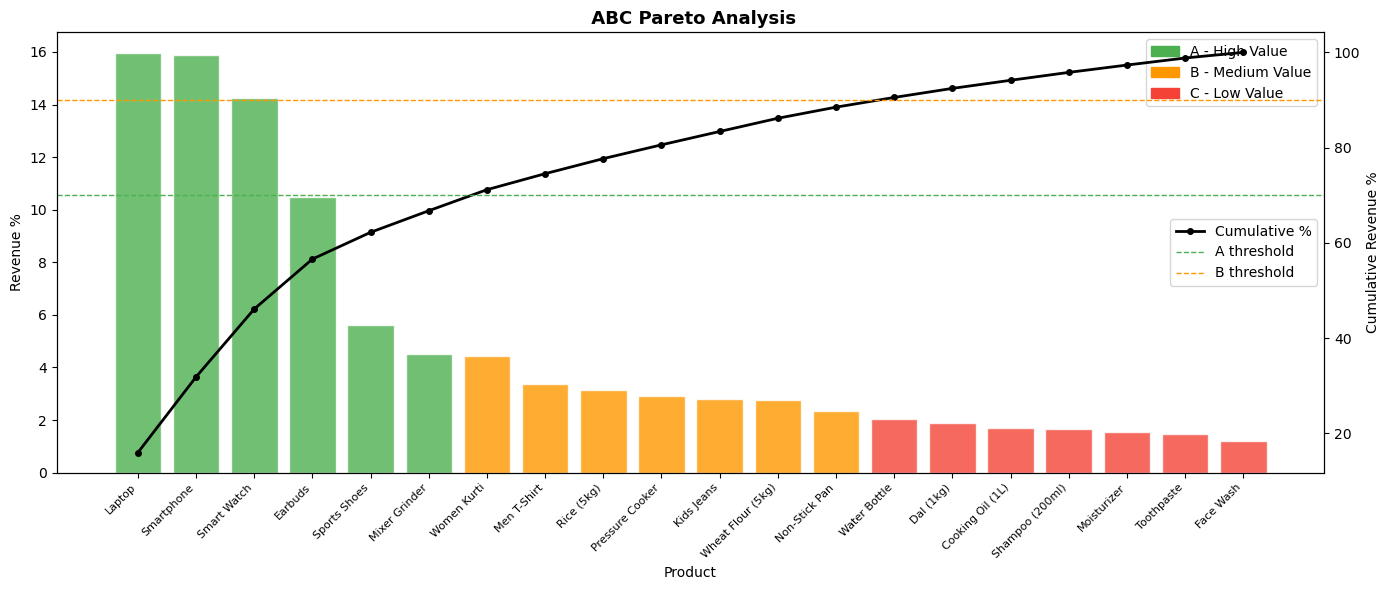

In [60]:
# ABC Analysis
abc_path = 'outputs/abc_analysis.csv'
if os.path.exists(abc_path):
    abc = pd.read_csv(abc_path)
    print('ABC Analysis Results:')
    print(abc[['product','category','abc_class','total_revenue','revenue_pct','cumulative_pct']].to_string(index=False))

    # Pareto chart
    fig, ax = plt.subplots(figsize=(14,6))
    ax2 = ax.twinx()

    abc_colors = {'A':'#4CAF50','B':'#FF9800','C':'#F44336'}
    bar_colors = [abc_colors.get(c,'gray') for c in abc['abc_class']]

    ax.bar(abc['product'], abc['revenue_pct'], color=bar_colors, alpha=0.8, edgecolor='white')
    ax2.plot(abc['product'], abc['cumulative_pct'], 'k-o', linewidth=2, markersize=4, label='Cumulative %')
    ax2.axhline(70, linestyle='--', color='#4CAF50', linewidth=1, label='A threshold')
    ax2.axhline(90, linestyle='--', color='#FF9800', linewidth=1, label='B threshold')

    ax.set_xlabel('Product')
    ax.set_ylabel('Revenue %')
    ax2.set_ylabel('Cumulative Revenue %')
    ax.set_title(' ABC Pareto Analysis', fontsize=13, fontweight='bold')
    ax.set_xticklabels(abc['product'], rotation=45, ha='right', fontsize=8)
    ax2.legend(loc='center right')

    # Legend patches for ABC
    from matplotlib.patches import Patch
    legend = [Patch(color='#4CAF50', label='A - High Value'),
              Patch(color='#FF9800', label='B - Medium Value'),
              Patch(color='#F44336', label='C - Low Value')]
    ax.legend(handles=legend, loc='upper right')

    plt.tight_layout()
    plt.savefig('images/nb_08_abc_pareto.png', dpi=120)
    plt.show()

In [61]:
# Business KPI Summary
raw = pd.read_csv('data/raw_sales_data.csv', parse_dates=['date'])

total_revenue    = raw['revenue'].sum()
stockout_rate    = raw['stockout_flag'].mean() * 100
total_lost_sales = raw['lost_sales'].sum() if 'lost_sales' in raw.columns else 0
lost_revenue     = (raw['lost_sales'] * raw['unit_price']).sum() if 'lost_sales' in raw.columns else 0

print('='*55)
print('   BEFORE vs AFTER OPTIMIZATION')
print('='*55)
print(f'  Total Revenue                : ₹{total_revenue:>12,.0f}')
print(f'  Stockout Rate (Before)       : {stockout_rate:>10.1f}%')
print(f'  Stockout Rate (After est.)   : {stockout_rate*0.4:>10.1f}%')
print(f'  Total Lost Units             : {total_lost_sales:>12,.0f}')
print(f'  Estimated Lost Revenue       : ₹{lost_revenue:>12,.0f}')
print(f'  Projected Revenue Recovery   : ₹{lost_revenue*0.60:>12,.0f}')
print('='*55)
print('\n  This shows the BUSINESS VALUE of the system!')

   BEFORE vs AFTER OPTIMIZATION
  Total Revenue                : ₹13,679,063,587
  Stockout Rate (Before)       :        0.8%
  Stockout Rate (After est.)   :        0.3%
  Total Lost Units             :       29,591
  Estimated Lost Revenue       : ₹ 101,308,381
  Projected Revenue Recovery   : ₹  60,785,029

  This shows the BUSINESS VALUE of the system!
